In [1]:
# ── Detección de entorno ──────────────────────────────────────────────────────
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f'Entorno: {"Colab" if IN_COLAB else "Local"}')

Entorno: Colab


In [2]:
# ── Rutas ─────────────────────────────────────────────────────────────────────
from pathlib import Path

if IN_COLAB:
    drive.mount('/content/drive')
    DRIVE_ROOT   = Path('/content/drive/MyDrive/ham10000-augmentation')
    SYNTH_ROOT   = DRIVE_ROOT / 'synthetic'  # leer directo, sin copiar
    IMAGES_DIR   = None   # se resuelve al extraer el zip
    SPLITS_DIR   = None   # se resuelve al extraer el zip
    PROJECT_ROOT = Path('/content')
else:
    PROJECT_ROOT = Path.cwd()
    SYNTH_ROOT   = PROJECT_ROOT / 'data' / 'synthetic'
    IMAGES_DIR   = PROJECT_ROOT / 'data' / 'processed' / 'images'
    SPLITS_DIR   = PROJECT_ROOT / 'data' / 'processed' / 'splits'

OUT_DIR = PROJECT_ROOT / 'figures'
OUT_DIR.mkdir(exist_ok=True)


Mounted at /content/drive


In [3]:
# ── Dependencias ──────────────────────────────────────────────────────────────
import sys, subprocess

try:
    import pandas as pd
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'pandas'])
    import pandas as pd

try:
    from PIL import Image
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'Pillow'])
    from PIL import Image

import random
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# ── Extracción de datos reales (Colab) ────────────────────────────────────────
if IN_COLAB:
    import zipfile

    _zip_new = DRIVE_ROOT / 'data' / 'classification_data.zip'
    _zip_old = DRIVE_ROOT / 'classification_data.zip'
    zip_path     = _zip_new if _zip_new.exists() else _zip_old
    extract_path = Path('/content/classification_data')

    if not extract_path.exists():
        print('Descomprimiendo classification_data.zip ...')
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(extract_path)

    splits_found = list(extract_path.rglob('train.csv'))
    SPLITS_DIR   = splits_found[0].parent if splits_found else None
    jpgs         = list(extract_path.rglob('*.jpg'))
    IMAGES_DIR   = jpgs[0].parent if jpgs else None

    print(f'  SYNTH_ROOT : {SYNTH_ROOT}  (existe: {SYNTH_ROOT.exists()})')
    print(f'  SPLITS_DIR : {SPLITS_DIR}  (existe: {SPLITS_DIR.exists() if SPLITS_DIR else False})')
    print(f'  IMAGES_DIR : {IMAGES_DIR}')


Descomprimiendo classification_data.zip ...
  SYNTH_ROOT : /content/drive/MyDrive/ham10000-augmentation/synthetic  (existe: True)
  SPLITS_DIR : /content/classification_data/splits  (existe: True)
  IMAGES_DIR : /content/classification_data/images


In [5]:
# ── Estado actual ─────────────────────────────────────────────────────────────
METHODS = {
    'real_mel':          None,              # se resuelve desde train.csv
    'textual_inversion': SYNTH_ROOT / 'textual_inversion',
    'gan_final':         SYNTH_ROOT / 'gan_final',
    'lora':              SYNTH_ROOT / 'lora',
    'derm_s005':         SYNTH_ROOT / 'derm_s005',
}

print('Estado de grids en figures/:')
for name in METHODS:
    out = OUT_DIR / f'grid_{name}.png'
    status = '✅ ya existe' if out.exists() else '⬜ pendiente'
    src = METHODS[name]
    avail = '—' if src is None else ('✅' if src.exists() else '❌ no encontrado')
    print(f'  {name:25s}  grid={status}  fuente={avail}')

Estado de grids en figures/:
  real_mel                   grid=⬜ pendiente  fuente=—
  textual_inversion          grid=⬜ pendiente  fuente=✅
  gan_final                  grid=⬜ pendiente  fuente=✅
  lora                       grid=⬜ pendiente  fuente=✅
  derm_s005                  grid=⬜ pendiente  fuente=✅


In [6]:
# ── Función de generación de grid ─────────────────────────────────────────────
SEED   = 42
NROWS  = 2
NCOLS  = 3
N      = NROWS * NCOLS
DPI    = 300
IMSIZE = 224  # px por imagen antes de componer el grid

def make_grid(image_paths, out_path, seed=SEED):
    """Genera grid NROWS×NCOLS sin ejes, títulos ni márgenes."""
    rng = random.Random(seed)
    sampled = rng.sample(image_paths, min(N, len(image_paths)))

    fig, axes = plt.subplots(NROWS, NCOLS,
                             figsize=(NCOLS * 1.5, NROWS * 1.5))
    fig.subplots_adjust(wspace=0.02, hspace=0.02,
                        left=0, right=1, top=1, bottom=0)

    for ax, path in zip(axes.flat, sampled):
        img = Image.open(path).convert('RGB').resize((IMSIZE, IMSIZE))
        ax.imshow(np.array(img))
        ax.axis('off')

    fig.savefig(out_path, dpi=DPI, bbox_inches='tight', pad_inches=0.01)
    plt.close(fig)
    print(f'  Guardado: {out_path.name}')

def collect_images(directory):
    """Retorna lista de paths .jpg/.png en un directorio."""
    paths = list(directory.glob('*.jpg')) + list(directory.glob('*.png'))
    return sorted(paths)

Imágenes de melanoma disponibles: 801
  Guardado: grid_real_mel.png


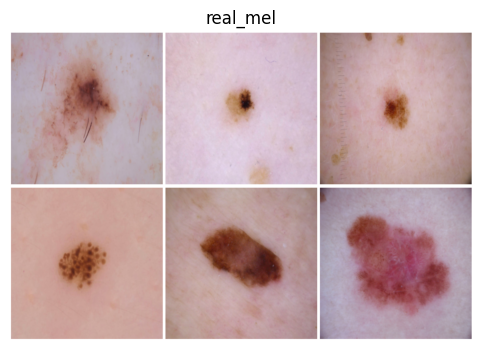

In [7]:
# ── Grid de melanomas reales ───────────────────────────────────────────────────
out_real = OUT_DIR / 'grid_real_mel.png'

if out_real.exists():
    print('grid_real_mel.png ya existe — saltando')
else:
    train_csv = SPLITS_DIR / 'train.csv'
    df = pd.read_csv(train_csv)
    mel_ids = df[df['dx'] == 'mel']['image_id'].tolist()

    def _resolve(img_id):
        p = IMAGES_DIR / (img_id + '.jpg')
        return p if p.exists() else IMAGES_DIR / img_id

    mel_paths = [_resolve(i) for i in mel_ids]
    mel_paths = [p for p in mel_paths if p.exists()]
    print(f'Imágenes de melanoma disponibles: {len(mel_paths)}')

    make_grid(mel_paths, out_real)

img = Image.open(out_real)
plt.figure(figsize=(6, 4))
plt.imshow(img); plt.axis('off'); plt.title('real_mel'); plt.show()

In [8]:
# ── Grids de métodos sintéticos ───────────────────────────────────────────────
SYNTH_METHODS = {
    'textual_inversion': SYNTH_ROOT / 'textual_inversion',
    'gan_final':         SYNTH_ROOT / 'gan_final',
    'lora':              SYNTH_ROOT / 'lora',
    'derm_s040':         SYNTH_ROOT / 'derm_s040',
    'derm_s005':         SYNTH_ROOT / 'derm_s005',
}

for name, src_dir in SYNTH_METHODS.items():
    out_path = OUT_DIR / f'grid_{name}.png'

    if out_path.exists():
        print(f'{name}: ya existe — saltando')
        continue

    if not src_dir.exists():
        print(f'{name}: directorio no encontrado ({src_dir}) — saltando')
        continue

    paths = collect_images(src_dir)
    if len(paths) < N:
        print(f'{name}: solo {len(paths)} imágenes disponibles (necesita {N}) — saltando')
        continue

    print(f'{name}: {len(paths)} imágenes encontradas')
    make_grid(paths, out_path)

print('\nResumen final:')
for name in ['real_mel'] + list(SYNTH_METHODS):
    out = OUT_DIR / f'grid_{name}.png'
    print(f'  {name:25s}  {"✅" if out.exists() else "❌"}')

textual_inversion: 4500 imágenes encontradas
  Guardado: grid_textual_inversion.png
gan_final: 5000 imágenes encontradas
  Guardado: grid_gan_final.png
lora: 4501 imágenes encontradas
  Guardado: grid_lora.png
derm_s040: 1602 imágenes encontradas
  Guardado: grid_derm_s040.png
derm_s005: 1602 imágenes encontradas
  Guardado: grid_derm_s005.png

Resumen final:
  real_mel                   ✅
  textual_inversion          ✅
  gan_final                  ✅
  lora                       ✅
  derm_s040                  ✅
  derm_s005                  ✅


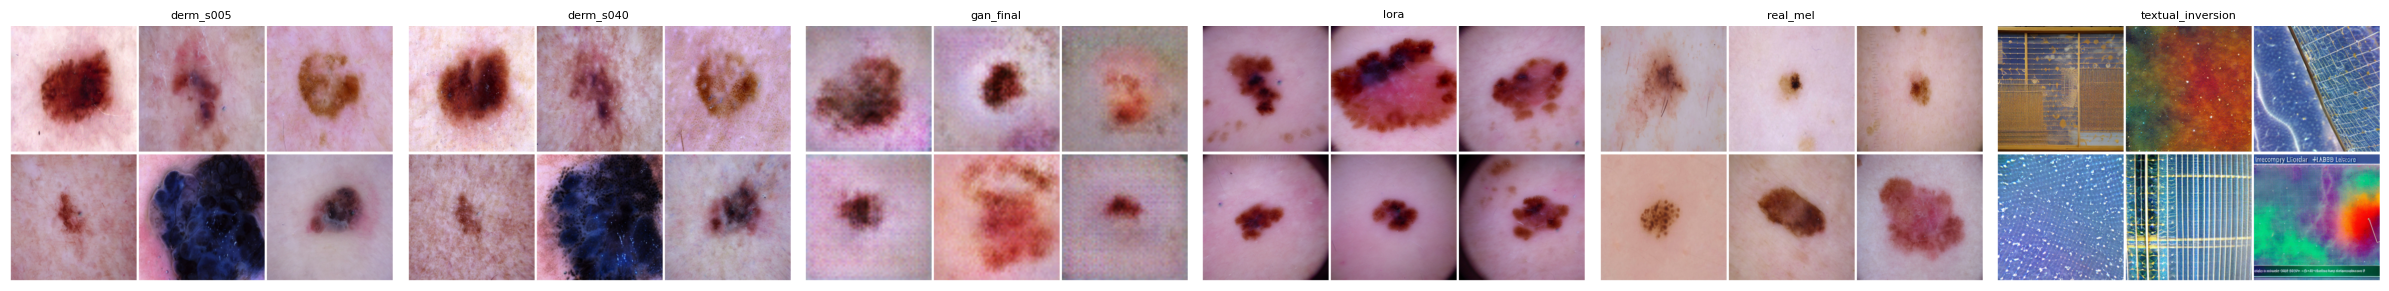

In [9]:
# ── Vista previa de todos los grids generados ─────────────────────────────────
generated = sorted(OUT_DIR.glob('grid_*.png'))
fig, axes = plt.subplots(1, len(generated), figsize=(4 * len(generated), 4))
if len(generated) == 1:
    axes = [axes]

for ax, path in zip(axes, generated):
    ax.imshow(Image.open(path))
    ax.set_title(path.stem.replace('grid_', ''), fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()